# Configuración del Entorno e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
import os

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, f1_score, recall_score,
                             accuracy_score)
import xgboost as xgb
import optuna
from scipy.stats import wilcoxon, shapiro, t as t_dist

# ============================================================
# REPRODUCIBILIDAD GLOBAL
# ============================================================
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

OUTPUT_DIR = "resultados_optuna"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"XGBoost version: {xgb.__version__}")
print(f"GPU Support: {xgb.build_info()['USE_CUDA']}")
print(f"Optuna version: {optuna.__version__}")
print(f"Directorio de salida: {OUTPUT_DIR}")

sns.set_theme(style="whitegrid", context="paper")

XGBoost version: 3.3.0
GPU Support: True
Optuna version: 4.9.0
Directorio de salida: resultados_optuna


# Carga y Preprocesamiento de Datos

In [2]:
df = pd.read_csv('../../../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Distribución de clases:\n{df['target'].value_counts()}")
print(f"Prevalencia clase positiva: {df['target'].mean():.4f}")

Dimensiones del dataset: (30000, 24)
Distribución de clases:
target
0    23364
1     6636
Name: count, dtype: int64
Prevalencia clase positiva: 0.2212


# División Train/Test y Cálculo de Scale Pos Weight

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Clase 0: {neg} | Clase 1: {pos}")
print(f"Scale Pos Weight: {base_scale_pos_weight:.4f}")

Train: (24000, 23) | Test: (6000, 23)
Clase 0: 18691 | Clase 1: 5309
Scale Pos Weight: 3.5206


# Función de Evaluación Completa

In [4]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Modelo"):
    """Evalúa y retorna todas las métricas + matriz de confusión."""
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"--- {model_name} ---")
    print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | "
          f"F1: {f1:.4f} | Recall: {rec:.4f} | Acc: {acc:.4f}")
    print(f"TP={tp} | FP={fp} | TN={tn} | FN={fn}")
    
    return {
        "pr_auc": pr_auc, "roc_auc": roc_auc, "f1": f1,
        "recall": rec, "accuracy": acc,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)
    }

# Entrenamiento del Modelo Base XGBoost

In [5]:
t0 = time.time()
model_base = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=base_scale_pos_weight,
    tree_method='hist', device='cuda', eval_metric='aucpr',
    random_state=GLOBAL_SEED, verbosity=0
)
model_base.fit(X_train, y_train, verbose=False)
t_base = time.time() - t0

y_pred_base = model_base.predict(X_test)
y_prob_base = model_base.predict_proba(X_test)[:, 1]
metrics_base = evaluate_model(y_test, y_pred_base, y_prob_base, "MODELO BASE")
print(f"⏱️ Tiempo: {t_base:.1f}s")

--- MODELO BASE ---
PR-AUC: 0.5459 | ROC-AUC: 0.7687 | F1: 0.5307 | Recall: 0.5870 | Acc: 0.7703
TP=779 | FP=830 | TN=3843 | FN=548
⏱️ Tiempo: 1.3s


# Visualización del Modelo Base

💾 Guardado: resultados_optuna/eval_BASE.png


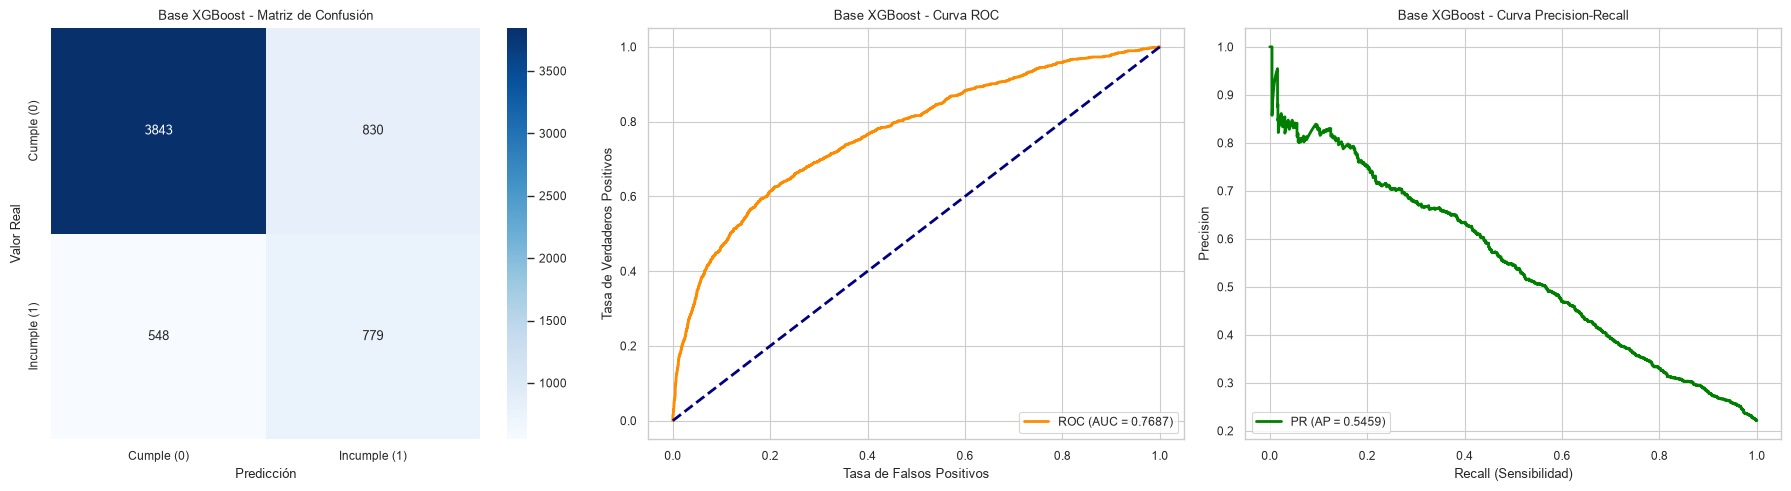

In [6]:
def plot_model_evaluation(y_true, y_pred, y_prob, title_prefix="Modelo",
                          save_path=None):
    """Genera matriz de confusión, ROC y PR. Opcionalmente guarda."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[2].plot(recall, precision, color='green', lw=2,
                 label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f'{title_prefix} - Curva Precision-Recall')
    axes[2].legend(loc="lower left")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Guardado: {save_path}")
    plt.show()

plot_model_evaluation(y_test, y_pred_base, y_prob_base, "Base XGBoost",
                      save_path=f"{OUTPUT_DIR}/eval_BASE.png")

# Función Objetivo para Optuna
**IMPORTANTE:** La función objetivo usa la **misma media geométrica**
(sqrt(PR-AUC × F1)) con penalización por recall bajo que el notebook
GWO-MFO. NO es maximización directa de PR-AUC.

In [7]:
# Constantes globales (P-23: fuera de la función)
MIN_RECALL_THRESHOLD = 0.55
PENALTY_LAMBDA = 0.8

def objective_function_optuna(trial):
    """Función objetivo para Optuna.
    
    NOTA METODOLÓGICA: Usa la misma función compuesta que GWO-MFO:
    score = sqrt(PR-AUC × F1) - penalty(recall < 0.55)
    
    DIFERENCIA con GWO-MFO: learning_rate usa escala LOGARÍTMICA
    (trial.suggest_float con log=True), mientras que GWO-MFO usa
    escala LINEAL. Esto favorece la exploración de valores bajos
    de learning_rate en Optuna.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2.0, 5.0),
        'tree_method': 'hist',
        'device': 'cuda',
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 30,
        'random_state': GLOBAL_SEED,
        'verbosity': 0
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=GLOBAL_SEED)
    scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1]
        
        pr_auc = average_precision_score(y_val, y_pred_prob)
        f1 = f1_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        
        combined_score = np.sqrt(pr_auc * f1)
        penalty = max(0.0, (MIN_RECALL_THRESHOLD - rec) * PENALTY_LAMBDA)
        scores.append(combined_score - penalty)
        
    return np.mean(scores)

# Optimización Optuna - Escenario A (300 trials / 900 OFEs)

In [8]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# P-5: Semilla explícita para reproducibilidad
sampler_A = optuna.samplers.TPESampler(seed=GLOBAL_SEED)
study_A = optuna.create_study(
    direction='maximize',
    study_name="XGBoost_Optuna_Scenario_A",
    sampler=sampler_A
    # P-3: Si se desea MedianPruner, descomentar:
    # pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)

t0 = time.time()
study_A.optimize(objective_function_optuna, n_trials=300, show_progress_bar=True)
t_optuna_A = time.time() - t0

print(f"✅ Escenario A completado en {t_optuna_A:.1f}s")
print(f"OFEs reales: 300 × 3 = {300*3}")
print(f"Mejor score (CV): {study_A.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_A.best_params}")

best_params_A = study_A.best_params

# P-18: Guardar historial de trials
trials_A_df = study_A.trials_dataframe()
trials_A_df.to_csv(f"{OUTPUT_DIR}/trials_A.csv", index=False)
print(f"💾 Historial de trials A guardado ({len(trials_A_df)} trials)")

  0%|          | 0/300 [00:00<?, ?it/s]

✅ Escenario A completado en 390.2s
OFEs reales: 300 × 3 = 900
Mejor score (CV): 0.5552
Mejores hiperparámetros: {'n_estimators': 281, 'max_depth': 7, 'learning_rate': 0.016688817634015748, 'subsample': 0.6415273982682645, 'colsample_bytree': 0.8102863339904179, 'scale_pos_weight': 3.11971285382666}
💾 Historial de trials A guardado (300 trials)


# Entrenamiento Final Optuna (Escenario A)

--- OPTUNA (300 Trials) ---
PR-AUC: 0.5541 | ROC-AUC: 0.7772 | F1: 0.5450 | Recall: 0.5818 | Acc: 0.7852
TP=772 | FP=734 | TN=3939 | FN=555
💾 Guardado: resultados_optuna/eval_OPTUNA_300.png


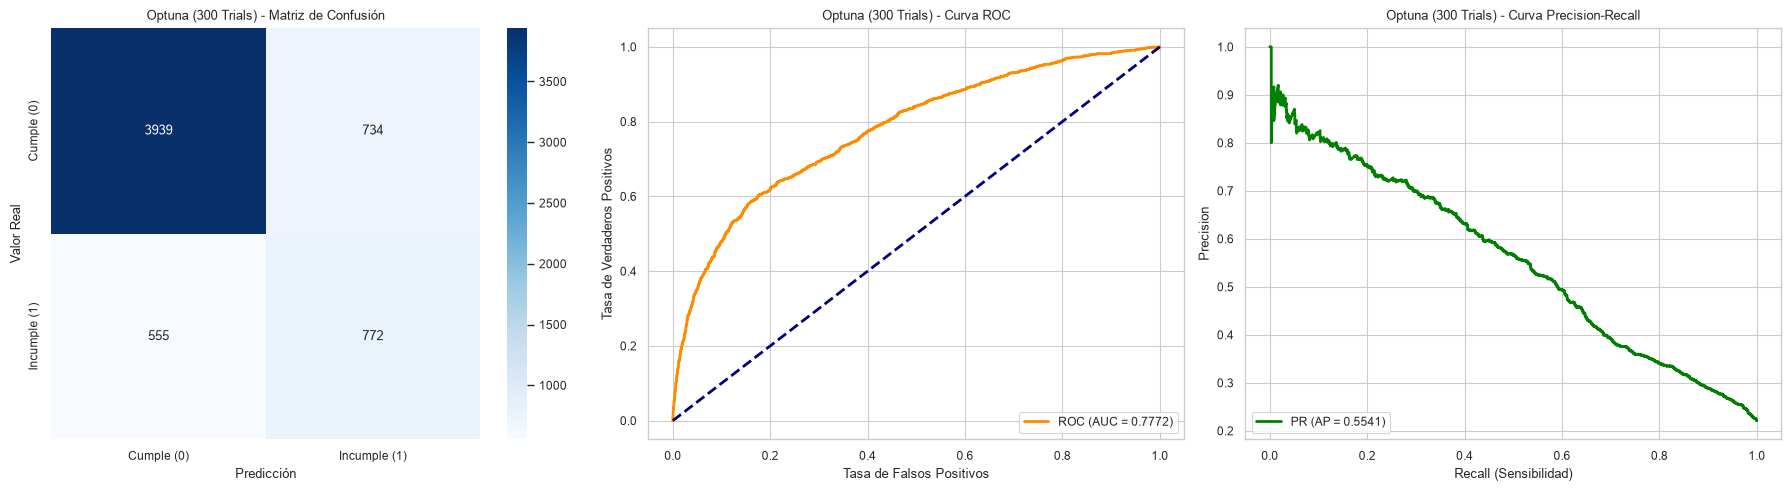

In [9]:
model_optuna_A = xgb.XGBClassifier(
    **best_params_A,
    tree_method='hist', device='cuda', eval_metric='aucpr',
    random_state=GLOBAL_SEED, verbosity=0
)
model_optuna_A.fit(X_train, y_train, verbose=False)

y_pred_A = model_optuna_A.predict(X_test)
y_prob_A = model_optuna_A.predict_proba(X_test)[:, 1]
metrics_A = evaluate_model(y_test, y_pred_A, y_prob_A, "OPTUNA (300 Trials)")

plot_model_evaluation(y_test, y_pred_A, y_prob_A, "Optuna (300 Trials)",
                      save_path=f"{OUTPUT_DIR}/eval_OPTUNA_300.png")

# Optimización Optuna - Escenario B (600 trials / 1800 OFEs)

In [10]:
sampler_B = optuna.samplers.TPESampler(seed=GLOBAL_SEED)
study_B = optuna.create_study(
    direction='maximize',
    study_name="XGBoost_Optuna_Scenario_B",
    sampler=sampler_B
)

t0 = time.time()
study_B.optimize(objective_function_optuna, n_trials=600, show_progress_bar=True)
t_optuna_B = time.time() - t0

print(f"✅ Escenario B completado en {t_optuna_B:.1f}s")
print(f"OFEs reales: 600 × 3 = {600*3}")
print(f"Mejor score (CV): {study_B.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_B.best_params}")

best_params_B = study_B.best_params

trials_B_df = study_B.trials_dataframe()
trials_B_df.to_csv(f"{OUTPUT_DIR}/trials_B.csv", index=False)
print(f"💾 Historial de trials B guardado ({len(trials_B_df)} trials)")

  0%|          | 0/600 [00:00<?, ?it/s]

✅ Escenario B completado en 941.3s
OFEs reales: 600 × 3 = 1800
Mejor score (CV): 0.5556
Mejores hiperparámetros: {'n_estimators': 226, 'max_depth': 7, 'learning_rate': 0.01688724043566842, 'subsample': 0.6412067888033017, 'colsample_bytree': 0.7875774331123258, 'scale_pos_weight': 3.1050957316502164}
💾 Historial de trials B guardado (600 trials)


# Entrenamiento Final Optuna (Escenario B)

--- OPTUNA (600 Trials) ---
PR-AUC: 0.5543 | ROC-AUC: 0.7777 | F1: 0.5444 | Recall: 0.5772 | Acc: 0.7863
TP=766 | FP=721 | TN=3952 | FN=561
💾 Guardado: resultados_optuna/eval_OPTUNA_600.png


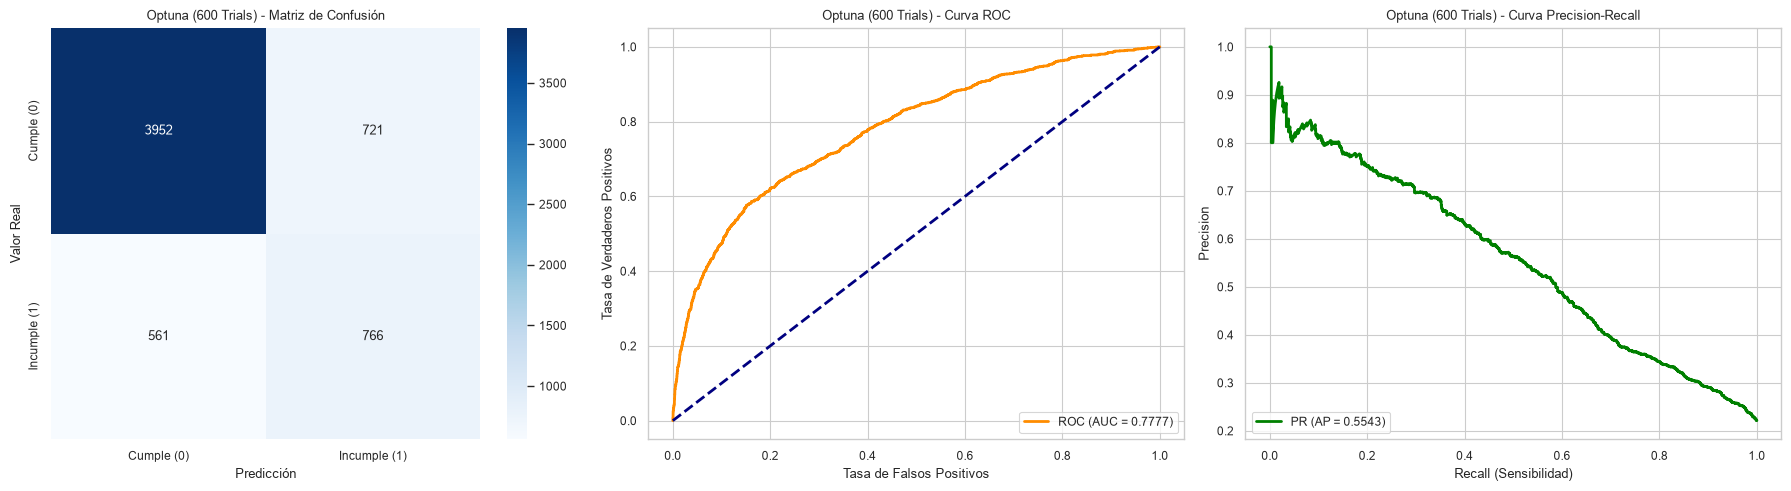

In [11]:
model_optuna_B = xgb.XGBClassifier(
    **best_params_B,
    tree_method='hist', device='cuda', eval_metric='aucpr',
    random_state=GLOBAL_SEED, verbosity=0
)
model_optuna_B.fit(X_train, y_train, verbose=False)

y_pred_B = model_optuna_B.predict(X_test)
y_prob_B = model_optuna_B.predict_proba(X_test)[:, 1]
metrics_B = evaluate_model(y_test, y_pred_B, y_prob_B, "OPTUNA (600 Trials)")

plot_model_evaluation(y_test, y_pred_B, y_prob_B, "Optuna (600 Trials)",
                      save_path=f"{OUTPUT_DIR}/eval_OPTUNA_600.png")

# Análisis de Convergencia de Optuna

💾 Convergencia guardada


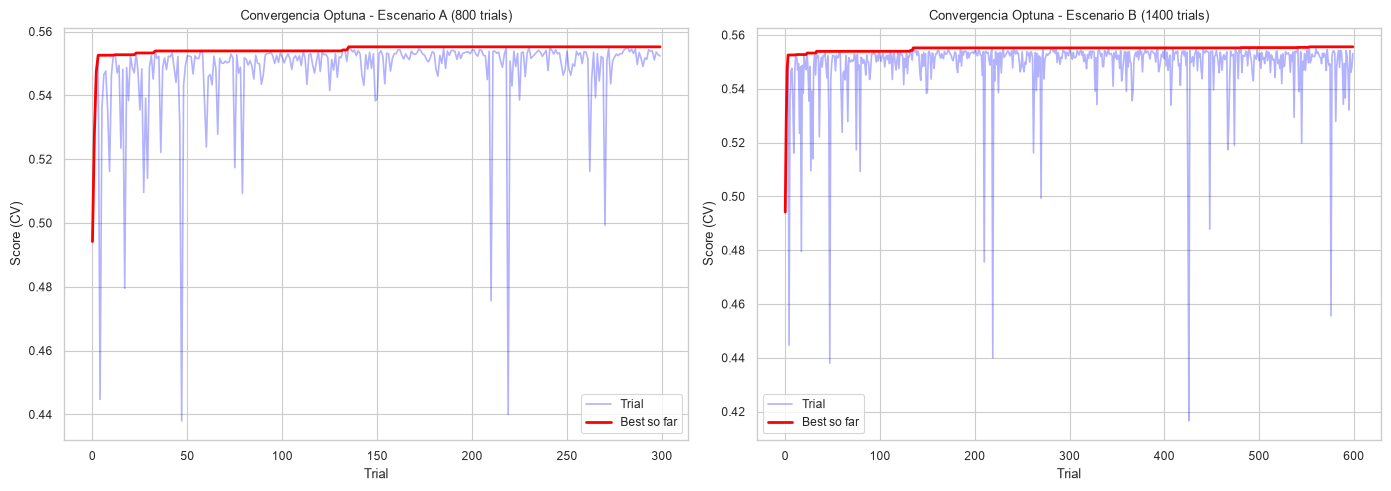

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escenario A
values_A = [t.value for t in study_A.trials if t.value is not None]
best_so_far_A = np.maximum.accumulate(values_A)
axes[0].plot(values_A, alpha=0.3, color='blue', label='Trial')
axes[0].plot(best_so_far_A, color='red', lw=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Score (CV)')
axes[0].set_title('Convergencia Optuna - Escenario A (300 trials)')
axes[0].legend()

# Escenario B
values_B = [t.value for t in study_B.trials if t.value is not None]
best_so_far_B = np.maximum.accumulate(values_B)
axes[1].plot(values_B, alpha=0.3, color='blue', label='Trial')
axes[1].plot(best_so_far_B, color='red', lw=2, label='Best so far')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Score (CV)')
axes[1].set_title('Convergencia Optuna - Escenario B (600 trials)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/convergencia_optuna.png", dpi=300, bbox_inches='tight')
print(f"💾 Convergencia guardada")
plt.show()

# Tabla Comparativa de Rendimiento

In [ ]:
all_metrics = {
    "XGBoost Base": metrics_base,
    "Optuna (300 trials)": metrics_A,
    "Optuna (600 trials)": metrics_B,
}

comparison_df = pd.DataFrame(all_metrics).T
comparison_df["Geo-Mean"] = np.sqrt(comparison_df["pr_auc"] * comparison_df["f1"])
comparison_df["Δ PR-AUC (%)"] = ((comparison_df["pr_auc"] / metrics_base["pr_auc"]) - 1) * 100

print("\n📊 TABLA COMPARATIVA")
print(comparison_df[["pr_auc","f1","recall","accuracy","Geo-Mean","Δ PR-AUC (%)"]].to_string())

comparison_df.to_csv(f"{OUTPUT_DIR}/tabla_comparativa.csv")
print(f"\n💾 Tabla exportada: {OUTPUT_DIR}/tabla_comparativa.csv")


📊 TABLA COMPARATIVA
                        pr_auc        f1    recall  accuracy  Geo-Mean  Δ PR-AUC (%)
XGBoost Base          0.545869  0.530654  0.587038  0.770333  0.538208      0.000000
Optuna (800 Trials)   0.554116  0.545005  0.581763  0.785167  0.549542      1.510811
Optuna (1400 Trials)  0.554337  0.544421  0.577242  0.786333  0.549356      1.551247

💾 Tabla exportada: resultados_optuna/tabla_comparativa.csv


# Análisis de Robustez Estadística (10 ejecuciones)

In [14]:
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021]

results = {"base": [], "optuna_A": [], "optuna_B": []}

# P-9: Función objetivo fuera del loop
def make_obj_optuna_robust(seed_val):
    """Crea función objetivo con semilla específica."""
    def obj(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2.0, 5.0),
            'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'aucpr',
            'early_stopping_rounds': 30, 'random_state': seed_val, 'verbosity': 0
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed_val)
        scores = []
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            m = xgb.XGBClassifier(**params)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            
            y_p = m.predict(X_val)
            y_p_prob = m.predict_proba(X_val)[:, 1]
            pr_auc = average_precision_score(y_val, y_p_prob)
            f1 = f1_score(y_val, y_p)
            rec = recall_score(y_val, y_p)
            
            combined = np.sqrt(pr_auc * f1)
            penalty = max(0.0, (MIN_RECALL_THRESHOLD - rec) * PENALTY_LAMBDA)
            scores.append(combined - penalty)
        return np.mean(scores)
    return obj

print(f"Iniciando análisis de robustez ({len(seeds)} ejecuciones)...")
t_robust_start = time.time()

for i, seed in enumerate(seeds):
    print(f"\n{'='*60}")
    print(f"Ejecución {i+1}/{len(seeds)} (Seed: {seed})")
    print(f"{'='*60}")
    
    # --- Modelo Base ---
    mb = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=base_scale_pos_weight,
        tree_method='hist', device='cuda', eval_metric='aucpr',
        random_state=seed, verbosity=0
    )
    mb.fit(X_train, y_train, verbose=False)
    results["base"].append(
        average_precision_score(y_test, mb.predict_proba(X_test)[:, 1])
    )
    
    # --- Optuna Escenario A (300 trials) ---
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sampler_rA = optuna.samplers.TPESampler(seed=seed)
    study_rA = optuna.create_study(direction='maximize', sampler=sampler_rA)
    study_rA.optimize(make_obj_optuna_robust(seed), n_trials=300,
                      show_progress_bar=False)
    bp_A = study_rA.best_params
    m_A = xgb.XGBClassifier(**bp_A, tree_method='hist', device='cuda',
                             eval_metric='aucpr', random_state=seed, verbosity=0)
    m_A.fit(X_train, y_train, verbose=False)
    results["optuna_A"].append(
        average_precision_score(y_test, m_A.predict_proba(X_test)[:, 1])
    )
    
    # --- Optuna Escenario B (600 trials) ---
    sampler_rB = optuna.samplers.TPESampler(seed=seed)
    study_rB = optuna.create_study(direction='maximize', sampler=sampler_rB)
    study_rB.optimize(make_obj_optuna_robust(seed), n_trials=600,
                      show_progress_bar=False)
    bp_B = study_rB.best_params
    m_B = xgb.XGBClassifier(**bp_B, tree_method='hist', device='cuda',
                             eval_metric='aucpr', random_state=seed, verbosity=0)
    m_B.fit(X_train, y_train, verbose=False)
    results["optuna_B"].append(
        average_precision_score(y_test, m_B.predict_proba(X_test)[:, 1])
    )
    
    # Checkpoint cada 5 ejecuciones
    if (i + 1) % 5 == 0:
        with open(f"{OUTPUT_DIR}/robustness_checkpoint.json", "w") as f:
            json.dump({"seeds": seeds[:i+1], "results": results}, f, indent=2)
        print(f"💾 Checkpoint guardado (ejecución {i+1})")

t_robust_total = time.time() - t_robust_start
print(f"\n✅ Robustez completada en {t_robust_total/3600:.2f} horas")

# P-24: Verificación de integridad
for key in results:
    assert len(results[key]) == len(seeds), \
        f"⚠️ {key} tiene {len(results[key])} resultados, esperados {len(seeds)}"

# Guardado final
with open(f"{OUTPUT_DIR}/robustness_results.json", "w") as f:
    json.dump({"seeds": seeds, "results": results,
               "total_time_hours": t_robust_total/3600}, f, indent=2)
print(f"💾 Resultados guardados: {OUTPUT_DIR}/robustness_results.json")

Iniciando análisis de robustez (10 ejecuciones)...

Ejecución 1/10 (Seed: 42)

Ejecución 2/10 (Seed: 123)

Ejecución 3/10 (Seed: 456)

Ejecución 4/10 (Seed: 789)

Ejecución 5/10 (Seed: 1011)
💾 Checkpoint guardado (ejecución 5)

Ejecución 6/10 (Seed: 1213)

Ejecución 7/10 (Seed: 1415)

Ejecución 8/10 (Seed: 1617)

Ejecución 9/10 (Seed: 1819)

Ejecución 10/10 (Seed: 2021)
💾 Checkpoint guardado (ejecución 10)

✅ Robustez completada en 2.93 horas
💾 Resultados guardados: resultados_optuna/robustness_results.json


# Análisis Estadístico Completo

In [15]:
# ============================================================
# INTERVALOS DE CONFIANZA 95%
# ============================================================
def ci_95(data):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(0.975, df=n-1)
    return m, m - t_crit * se, m + t_crit * se

print("\n📊 INTERVALOS DE CONFIANZA (95%)")
print(f"{'Modelo':30s} {'Media':>8s} {'IC_inf':>8s} {'IC_sup':>8s} {'Var':>12s}")
print("-" * 70)
for name, key in [("XGBoost Base", "base"),
                   ("Optuna (800)", "optuna_A"),
                   ("Optuna (1400)", "optuna_B")]:
    data = results[key]
    m, lo, hi = ci_95(data)
    v = np.var(data, ddof=1)
    print(f"{name:30s} {m:8.4f} {lo:8.4f} {hi:8.4f} {v:12.2e}")

# ============================================================
# SHAPIRO-WILK
# ============================================================
print("\n📊 SHAPIRO-WILK (normalidad)")
for name, key in [("Base", "base"), ("Optuna-A", "optuna_A"),
                   ("Optuna-B", "optuna_B")]:
    stat_sw, p_sw = shapiro(results[key])
    normal = "Normal" if p_sw > 0.05 else "No normal"
    print(f"  {name:15s}: W={stat_sw:.4f}, p={p_sw:.4f} → {normal}")

# ============================================================
# WILCOXON + HOLM-BONFERRONI + EFFECT SIZE
# ============================================================
comparisons = [
    ("Optuna-A vs Base",  "optuna_A", "base"),
    ("Optuna-B vs Base",  "optuna_B", "base"),
    ("Optuna-B vs Optuna-A", "optuna_B", "optuna_A"),
]

n_comp = len(comparisons)
n = len(seeds)
max_W = n * (n + 1) / 2

wilcoxon_results = []
for name, key_a, key_b in comparisons:
    W, p = wilcoxon(results[key_a], results[key_b], alternative='greater')
    r_rb = 1 - (2 * W) / max_W
    wilcoxon_results.append((name, W, p, r_rb))

wilcoxon_results.sort(key=lambda x: x[2])

print(f"\n{'='*90}")
print("WILCOXON + HOLM-BONFERRONI + EFFECT SIZE")
print(f"{'='*90}")
print(f"{'Comparación':30s} {'W':>5s} {'p':>10s} {'p_Holm':>10s} {'r_rb':>7s} {'Sig?':>5s}")
print("-" * 90)

for rank, (name, W, p, r_rb) in enumerate(wilcoxon_results):
    p_holm = min(p * (n_comp - rank), 1.0)
    sig = "✅" if p_holm < 0.05 else "❌"
    print(f"{name:30s} {W:5.0f} {p:10.6f} {p_holm:10.6f} {r_rb:7.3f} {sig:>5s}")

print(f"\n📊 Potencia: n={n}, p_min = {1/2**n:.6f}")


📊 INTERVALOS DE CONFIANZA (95%)
Modelo                            Media   IC_inf   IC_sup          Var
----------------------------------------------------------------------
XGBoost Base                     0.5448   0.5424   0.5473     1.19e-05
Optuna (800)                     0.5528   0.5498   0.5558     1.77e-05
Optuna (1400)                    0.5530   0.5505   0.5555     1.22e-05

📊 SHAPIRO-WILK (normalidad)
  Base           : W=0.9084, p=0.2701 → Normal
  Optuna-A       : W=0.8832, p=0.1421 → Normal
  Optuna-B       : W=0.9576, p=0.7580 → Normal

WILCOXON + HOLM-BONFERRONI + EFFECT SIZE
Comparación                        W          p     p_Holm    r_rb  Sig?
------------------------------------------------------------------------------------------
Optuna-A vs Base                  55   0.000977   0.002930  -1.000     ✅
Optuna-B vs Base                  55   0.000977   0.001953  -1.000     ✅
Optuna-B vs Optuna-A              21   0.589844   0.589844   0.236     ❌

📊 Potencia: n=10

# Boxplots PR-AUC

💾 Boxplot guardado


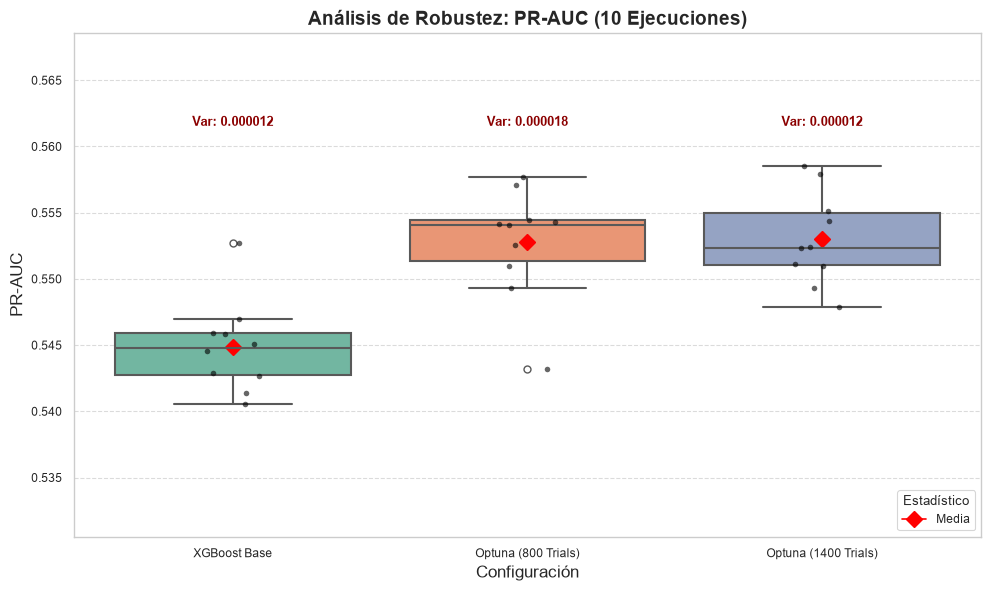

In [ ]:
plt.figure(figsize=(10, 6))

df_robust = pd.DataFrame({
    "XGBoost Base": results["base"],
    "Optuna (300 trials)": results["optuna_A"],
    "Optuna (600 trials)": results["optuna_B"]
}).melt(var_name="Modelo", value_name="PR-AUC")

ax = sns.boxplot(data=df_robust, x="Modelo", y="PR-AUC", palette="Set2",
                 linewidth=1.5, fliersize=5)
sns.stripplot(data=df_robust, x="Modelo", y="PR-AUC", color="black",
              size=4, alpha=0.6, jitter=True)

models_list = df_robust["Modelo"].unique()
means_list = [df_robust[df_robust["Modelo"] == m]["PR-AUC"].mean() for m in models_list]
vars_list = [df_robust[df_robust["Modelo"] == m]["PR-AUC"].var() for m in models_list]

for i, (model, mean) in enumerate(zip(models_list, means_list)):
    ax.plot(i, mean, marker='D', color='red', markersize=8,
            label='Media' if i == 0 else "")

plt.title("Análisis de Robustez: PR-AUC (10 Ejecuciones)",
          fontsize=14, fontweight='bold')
plt.ylabel("PR-AUC", fontsize=12)
plt.xlabel("Configuración", fontsize=12)
plt.ylim(min(df_robust["PR-AUC"]) - 0.01, max(df_robust["PR-AUC"]) + 0.01)
plt.legend(title="Estadístico", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (model, var, mean_val) in enumerate(zip(models_list, vars_list, means_list)):
    var_text = f'Var: {var:.2e}' if var < 0.00001 else f'Var: {var:.6f}'
    ax.annotate(var_text, xy=(i, mean_val),
                xytext=(i, max(df_robust["PR-AUC"]) + 0.003),
                ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Boxplot_PR-AUC_15_Ejecuciones.png",
            dpi=300, bbox_inches='tight')
print(f"💾 Boxplot guardado")
plt.show()

# Resumen de Tiempos y OFEs

In [17]:
print("\n📊 RESUMEN DE TIEMPOS Y OFEs")
print(f"{'Método':30s} {'Tiempo (s)':>12s} {'OFEs':>8s}")
print("-" * 55)
print(f"{'Modelo Base':30s} {t_base:12.1f} {'N/A':>8s}")
print(f"{'Optuna (300 trials)':30s} {t_optuna_A:12.1f} {300*3:8d}")
print(f"{'Optuna (600 trials)':30s} {t_optuna_B:12.1f} {600*3:8d}")
print(f"{'Robustez (total)':30s} {t_robust_total:12.1f} {'N/A':>8s}")


📊 RESUMEN DE TIEMPOS Y OFEs
Método                           Tiempo (s)     OFEs
-------------------------------------------------------
Modelo Base                             1.3      N/A
Optuna (300 trials)                   390.2      900
Optuna (600 trials)                   941.3     1800
Robustez (total)                    10550.7      N/A
